# Expression of type I interferon genes across datasets

Template to compare the expression change of type I IFN genes (log2FC from DESeq2 / PyDESeq2) across the AXL and comparator datasets (ERBB2, IGF1, OSM/OSMR/LIF). 

**Inputs**: one DESeq2 results table per dataset with columns `Gene.name`, `log2FoldChange`, `padj`. 

**Reading the plot**
- `*` padj < 0.05, `**` < 0.01, `***` < 0.001. No star = not significant.
- `n.d.` = gene absent from that table (not expressed / removed by the low-count filter / different annotation). This is not the same as no change.
- A gene with `padj = NA` (DESeq2 independent filtering or count outlier) is drawn without a star.
- The log2FC direction is `treatment vs control` for each dataset, so make sure the contrasts are all oriented as activation (or perturbation) vs control before comparing.

In [1]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import liana as li

## Configuration

In [2]:
# local checkout; on the cluster use /mnt/sds-hd/sd22b002/projects/ines/axl_networks
root_dir = '/mnt/sds-hd/sd22b002/projects/ines/axl_networks'
figures_dir = f'{root_dir}/figures'
os.makedirs(figures_dir, exist_ok=True)

# label shown in the legend -> DESeq2 results table (order = order of the bars)
datasets = {
    'AXL vs GFP': f'{root_dir}/data/CMV_GFP_4_GFP_new copy.csv',
    'ERBB2 vs WT (sham)': f'{root_dir}/results/erbb2/pydeseq2/GSE144391_ERBB2_sham_deseq2.csv',
    'ERBB2 vs WT (MI)': f'{root_dir}/results/erbb2/pydeseq2/GSE144391_ERBB2_MI_deseq2.csv',
    'hOSM vs Control': f'{root_dir}/results/osm_lif/pydeseq2/GSE185305_OSM_LIF_hosm_vs_control_deseq2.csv',
    'mOSM vs Control': f'{root_dir}/results/osm_lif/pydeseq2/GSE185305_OSM_LIF_mosm_vs_control_deseq2.csv',
    'mLIF vs Control': f'{root_dir}/results/osm_lif/pydeseq2/GSE185305_OSM_LIF_lif_vs_control_deseq2.csv', 
    'hOSM vs mOSM OE': f'{root_dir}/results/osm_lif/pydeseq2/GSE185305_OSM_LIF_hosm_vs_mosm_deseq2.csv',
    'IGF1 vs Control': f'{root_dir}/results/igf1/pydeseq2/GSE153763_IGF1_IGF1_vs_Control_deseq2.csv'
}

gene_col, lfc_col, padj_col, human_gene_col = 'Gene.name', 'log2FoldChange', 'padj', 'human_symbol',

# human symbols, grouped into categories for plotting.
gene_groups = {
    'Ligands': ['IFNB1', 'IFNA4', 'IFNE', 'IFNK'],
    'Receptor and signalling': ['IFNAR1', 'IFNAR2', 'JAK1', 'TYK2', 'STAT1', 'STAT2'],
    'IRFs': ['IRF1', 'IRF3', 'IRF7', 'IRF9'],
    'Nucleic-acid sensors': ['DDX58', 'IFIH1', 'TLR3', 'TLR7', 'ZBP1', 'CGAS', 'STING1', 'MAVS', 'TBK1'],
    'Type I ISGs': ['MX1', 'MX2', 'ISG15', 'IFIT1', 'IFIT2', 'IFIT3', 'OAS1', 'OAS2', 'OAS3', 'OASL', 'RSAD2', 'USP18', 'IFI44', 'CMPK2', 'BST2', 'XARF1', 'HERC5'],
    'Negative feedback': ['SOCS1', 'SOCS3'],
    'Shared with IFN-gamma (reference)': ['GBP1', 'GBP2', 'PSMB8', 'TAP1', 'CXCL10', 'CD274'],
}
panels_to_plot = list(gene_groups)   # subset this list to plot only some panels

star_levels = [(0.001, '***'), (0.01, '**'), (0.05, '*')]
out_prefix = 'ifn_type1'


# Settings for ortholog conversions
dataset_species = {label: 'mouse' for label in datasets}
dataset_species['IGF1 vs Control'] = 'rat'

hcop_min_evidence = 3   # same as the CORNETO notebooks

## Load the results tables and translate gene symbols to human

In [3]:
def load_orthologs(species):
    """Series: mouse/rat symbol -> human symbol, keeping only human symbols with a single source gene."""
    if species == 'mouse':
        m = li.rs.get_hcop_orthologs(
            url='https://ftp.ebi.ac.uk/pub/databases/genenames/hcop/human_mouse_hcop_fifteen_column.txt.gz',
            columns=['human_symbol', 'mouse_symbol'],
            min_evidence=hcop_min_evidence,
        )
    elif species == 'rat':
        m = pd.read_csv(f'{root_dir}/reference/human_rat_hcop_fifteen_column.txt', sep='\t')
        m = m[m['support'].str.split(',').str.len() >= hcop_min_evidence]
        m = m[['human_symbol', 'rat_symbol']]
    else:
        raise ValueError(f'Unknown species: {species}')

    m = m.rename(columns={f'{species}_symbol': 'source_symbol'})
    # remove genes without an ortholog in human
    m = m[(m['human_symbol'] != '-') & (m['source_symbol'] != '-')].drop_duplicates()
    # keep unique human genes (remove all duplicated human symbols to keep 1:1 orthologs)
    m = m[~m.duplicated(subset='human_symbol', keep=False)]
    return m.set_index('source_symbol')['human_symbol']

In [4]:
orthologs = {sp: load_orthologs(sp) for sp in set(dataset_species.values())}
orthologs

/home/hd/hd_hd/hd_kd353/miniforge3/envs/corneto/lib/python3.12/site-packages/liana/resource/_orthology.py:278: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.


{'rat': source_symbol
 A1cf          A1CF
 A2m            A2M
 A3galt2    A3GALT2
 A4galt      A4GALT
 A4gnt        A4GNT
             ...   
 Zyg11a      ZYG11A
 Zyg11b      ZYG11B
 Zyx            ZYX
 Zzef1        ZZEF1
 Zzz3          ZZZ3
 Name: human_symbol, Length: 16623, dtype: object,
 'mouse': source_symbol
 A1bg          A1BG
 A1cf          A1CF
 A3galt2    A3GALT2
 A4galt      A4GALT
 A4gnt        A4GNT
             ...   
 Zyg11a      ZYG11A
 Zyg11b      ZYG11B
 Zyx            ZYX
 Zzef1        ZZEF1
 Zzz3          ZZZ3
 Name: human_symbol, Length: 17177, dtype: object}

In [5]:
tables = {}
for label, path in datasets.items():
    if not os.path.exists(path):
        print(f'WARNING: {label}: file not found, skipped ({path})')
        continue
    df = pd.read_csv(path)
    missing_cols = {gene_col, lfc_col, padj_col} - set(df.columns)
    if missing_cols:
        raise ValueError(f'{label}: missing columns {missing_cols}; found {list(df.columns)}')
    df = df.drop_duplicates(gene_col).set_index(gene_col)[[lfc_col, padj_col]]

    # translate to human symbols (inner join: genes without a 1:1 ortholog are dropped)
    human = df.join(orthologs[dataset_species[label]].rename('human_symbol'), how='inner')
    tables[label] = human.set_index('human_symbol')
    print(f'{label} ({dataset_species[label]}): {len(df)} genes, {len(tables[label])} with a human ortholog')

labels = list(tables)
assert labels, 'No results tables were loaded'

AXL vs GFP (mouse): 22599 genes, 14548 with a human ortholog
ERBB2 vs WT (sham) (mouse): 23854 genes, 14509 with a human ortholog
ERBB2 vs WT (MI) (mouse): 23854 genes, 14509 with a human ortholog
hOSM vs Control (mouse): 19157 genes, 12728 with a human ortholog
mOSM vs Control (mouse): 19157 genes, 12728 with a human ortholog
mLIF vs Control (mouse): 19157 genes, 12728 with a human ortholog
hOSM vs mOSM OE (mouse): 19157 genes, 12728 with a human ortholog
IGF1 vs Control (rat): 17127 genes, 13020 with a human ortholog


In [6]:
# long table: one row per group x gene x dataset (genes listed in two groups appear twice)
rows = []
for group, genes in gene_groups.items():
    for gene in genes:
        for label in labels:
            t = tables[label]
            found = gene in t.index
            rows.append({
                'group': group, 'gene': gene, 'dataset': label, 'in_table': found,
                'log2FC': t.at[gene, lfc_col] if found else np.nan,
                'padj': t.at[gene, padj_col] if found else np.nan,
            })
long = pd.DataFrame(rows)

# genes missing from every dataset (check symbols / annotation)
absent = long.groupby('gene')['in_table'].any()
print('Not found in any dataset:', list(absent[~absent].index))

Not found in any dataset: ['DDX58', 'GBP1', 'HERC5', 'IFIT1', 'IFNA4', 'IFNB1', 'IFNE', 'IFNK', 'MX1', 'MX2', 'OAS1', 'XARF1']


## Barplot: log2FC per gene

Stars indicate statistical significance.

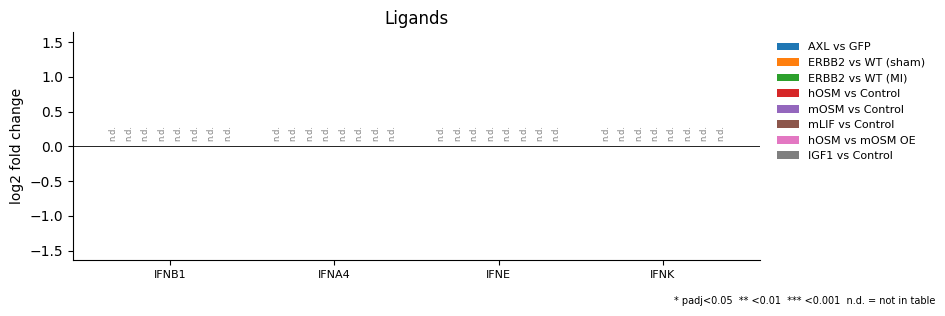

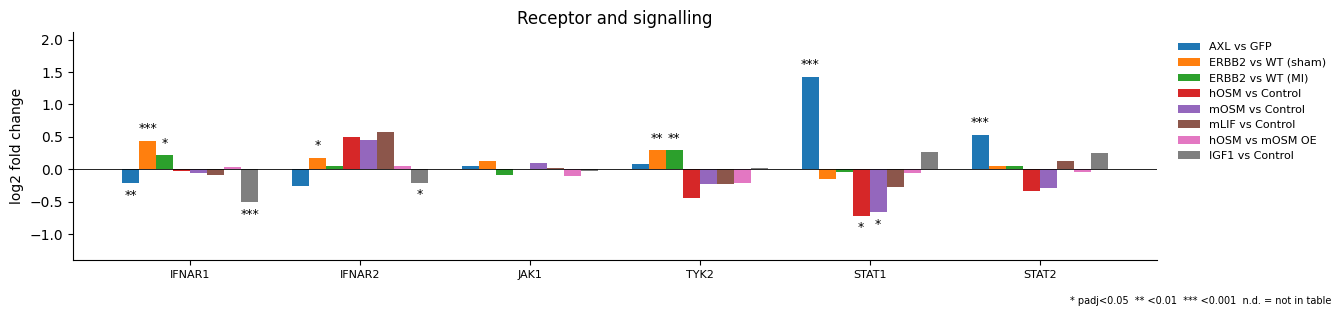

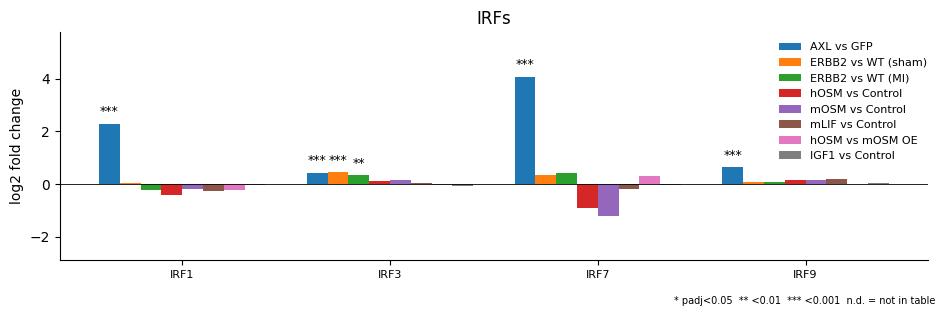

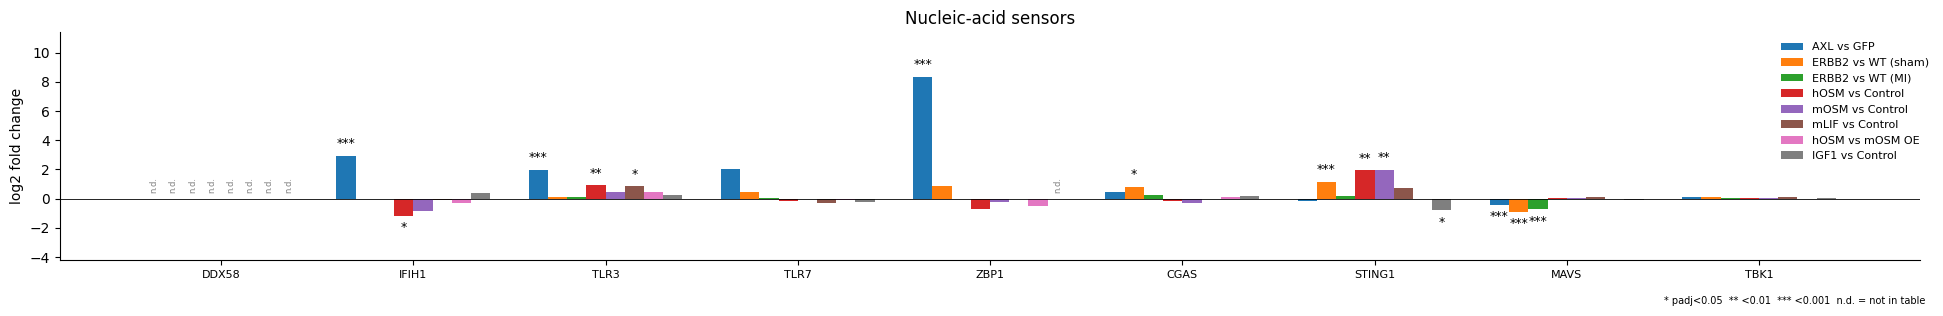

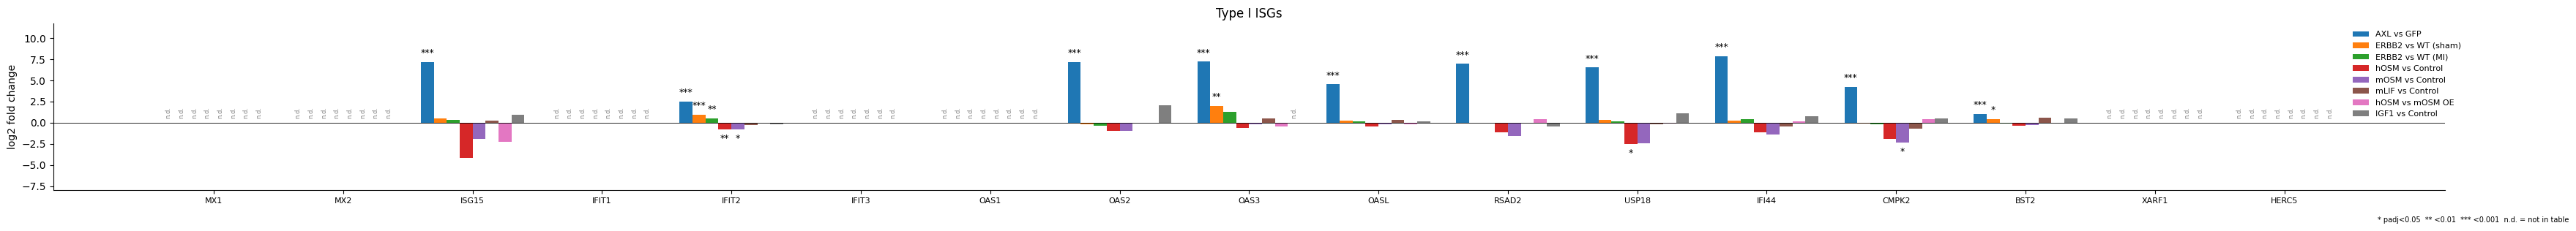

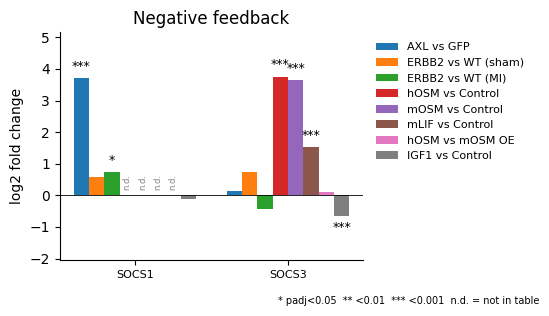

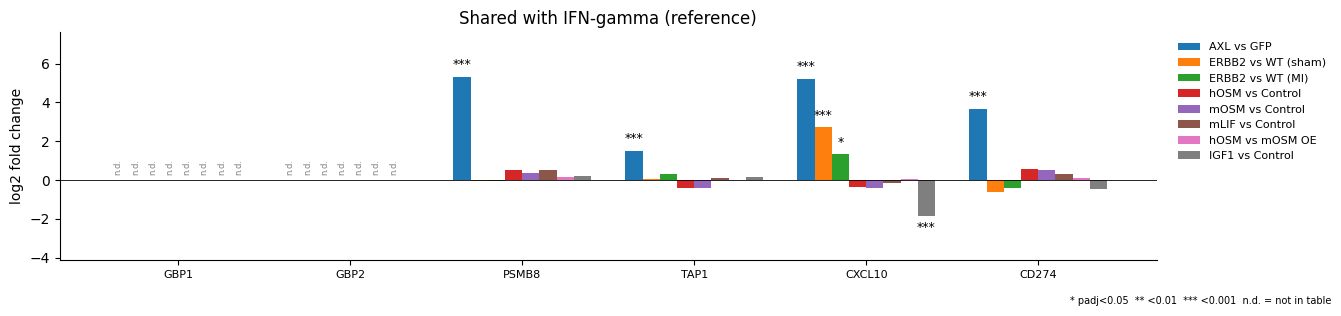

In [7]:
def stars(padj):
    if pd.isna(padj):
        return ''
    for cutoff, symbol in star_levels:
        if padj < cutoff:
            return symbol
    return ''

colors = dict(zip(labels, plt.cm.tab10.colors))
n_ds = len(labels)
bar_w = 0.8 / n_ds

for panel in panels_to_plot:
    genes = gene_groups[panel]
    sub = long[long.group == panel]

    # y-range from this group only, so small effects are not squashed by e.g. Mx1
    ymin, ymax = min(sub['log2FC'].min(), 0), max(sub['log2FC'].max(), 0)
    if np.isnan(ymin) or ymax == ymin:      # every gene n.d. in every dataset
        ymin, ymax = -1, 1
    pad = 0.04 * (ymax - ymin)

    fig, ax = plt.subplots(figsize=(max(3, 0.25 * n_ds * len(genes) + 1.5), 3))
    for j, label in enumerate(labels):
        s = sub[sub.dataset == label].set_index('gene').reindex(genes)
        x = np.arange(len(genes)) + (j - (n_ds - 1) / 2) * bar_w
        ax.bar(x, s['log2FC'].fillna(0), width=bar_w, color=colors[label], label=label)
        for xi, (gene, r) in zip(x, s.iterrows()):
            if not r['in_table']:
                ax.text(xi, pad, 'n.d.', rotation=90, ha='center', va='bottom', fontsize=6, color='grey')
                continue
            lfc = r['log2FC']
            y = lfc + pad if lfc >= 0 else lfc - pad
            ax.text(xi, y, stars(r['padj']), ha='center', va='bottom' if lfc >= 0 else 'top', fontsize=9)

    ax.axhline(0, color='black', lw=0.6)
    ax.set_xticks(np.arange(len(genes)))
    ax.set_xticklabels(genes, rotation=0, ha='center', fontsize=8)
    ax.set_ylim(ymin - 8 * pad, ymax + 8 * pad)
    ax.set_ylabel('log2 fold change')
    ax.set_title(panel)
    ax.spines[['top', 'right']].set_visible(False)
    ax.legend(frameon=False, fontsize=8, loc='best', bbox_to_anchor=(1.01, 1))
    fig.text(0.99, -0.03, '* padj<0.05  ** <0.01  *** <0.001  n.d. = not in table',
             ha='right', fontsize=7)
    plt.tight_layout()

    fname = panel.lower().replace(' ', '_').replace('(', '').replace(')', '').replace('-', '')
    plt.savefig(f'{figures_dir}/{out_prefix}_{fname}.png', dpi=300, bbox_inches='tight')
    plt.savefig(f'{figures_dir}/{out_prefix}_{fname}.pdf', bbox_inches='tight')
    plt.show()

## Heatmap: log2FC per gene x dataset
Same data as the barplots. Colour = log2FC (red up, blue down, clipped at `heatmap_lfc_cap`), stars = padj levels from `star_levels`, `n.d.` = gene not in that table. A grey cell without `n.d.` means the gene is in the table but its log2FC is NA. Run sections 2 and 3 first: they define `tables`, `labels`, `long`, `stars()` and `n_ds`.

### One heatmap per gene group

In [8]:
# colour scale is clipped at +/- this value so e.g. Mx1 (~9) does not wash out the rest; None = no cap
heatmap_lfc_cap = 4

def draw_lfc_heatmap(ax, genes, vmax, show_xticklabels=True):
    """Genes x datasets log2FC heatmap on `ax`, with significance stars and n.d. labels."""
    found = np.array([[g in tables[l].index for l in labels] for g in genes])
    lfc = np.array([[tables[l].at[g, lfc_col] if f else np.nan for l, f in zip(labels, row)]
                    for g, row in zip(genes, found)], dtype=float)
    padj = np.array([[tables[l].at[g, padj_col] if f else np.nan for l, f in zip(labels, row)]
                     for g, row in zip(genes, found)], dtype=float)

    cmap = plt.get_cmap('RdBu_r').copy()
    cmap.set_bad('lightgrey')
    im = ax.imshow(np.ma.masked_invalid(lfc), cmap=cmap, vmin=-vmax, vmax=vmax, aspect='auto')

    for i in range(len(genes)):
        for j in range(len(labels)):
            if not found[i, j]:
                ax.text(j, i, 'n.d.', ha='center', va='center', fontsize=6, color='dimgrey')
                continue
            s = stars(padj[i, j])
            if s:
                color = 'white' if abs(lfc[i, j]) > 0.6 * vmax else 'black'
                ax.text(j, i, s, ha='center', va='center', fontsize=8, color=color)

    ax.set_yticks(range(len(genes)))
    ax.set_yticklabels(genes, fontsize=8)
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels if show_xticklabels else [], rotation=90, ha='center', fontsize=8)
    ax.set_xticks(np.arange(-0.5, len(labels), 1), minor=True)
    ax.set_yticks(np.arange(-0.5, len(genes), 1), minor=True)
    ax.grid(which='minor', color='white', linewidth=0.5)
    ax.tick_params(which='minor', length=0)
    return im

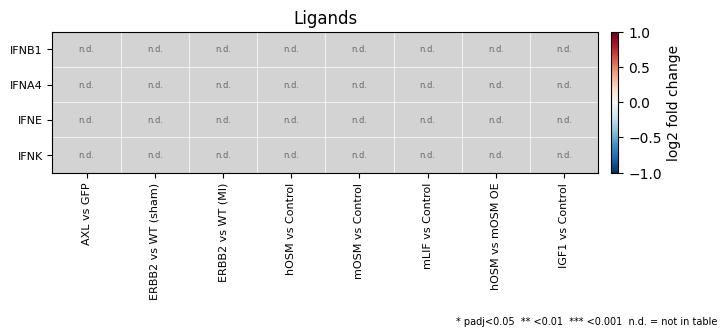

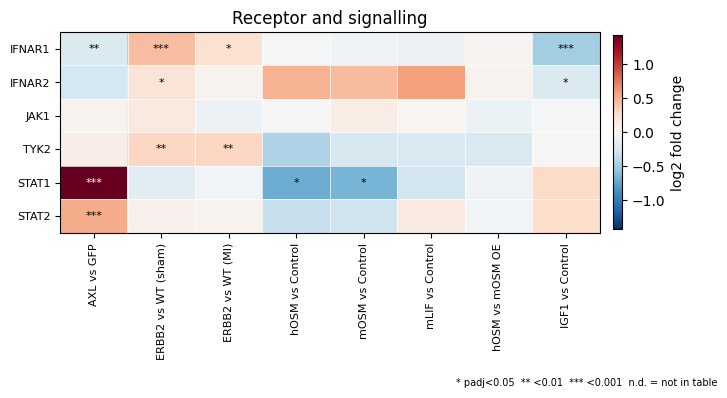

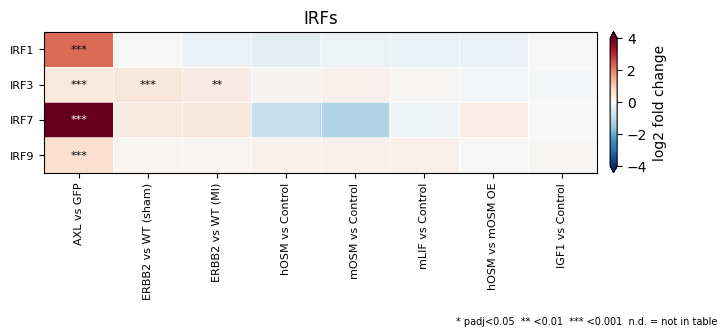

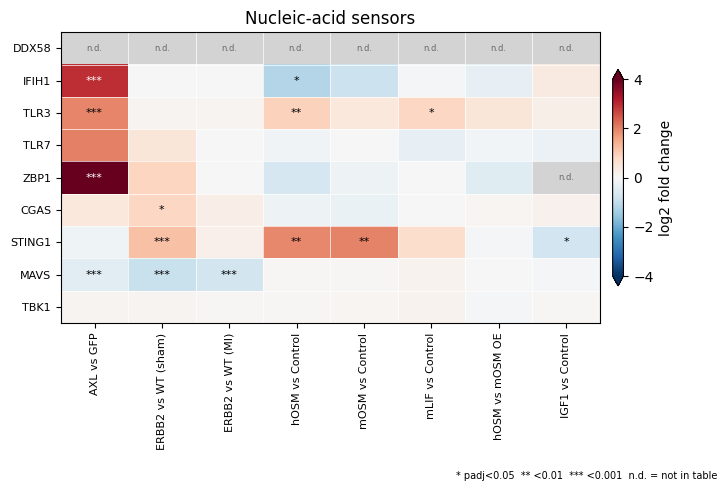

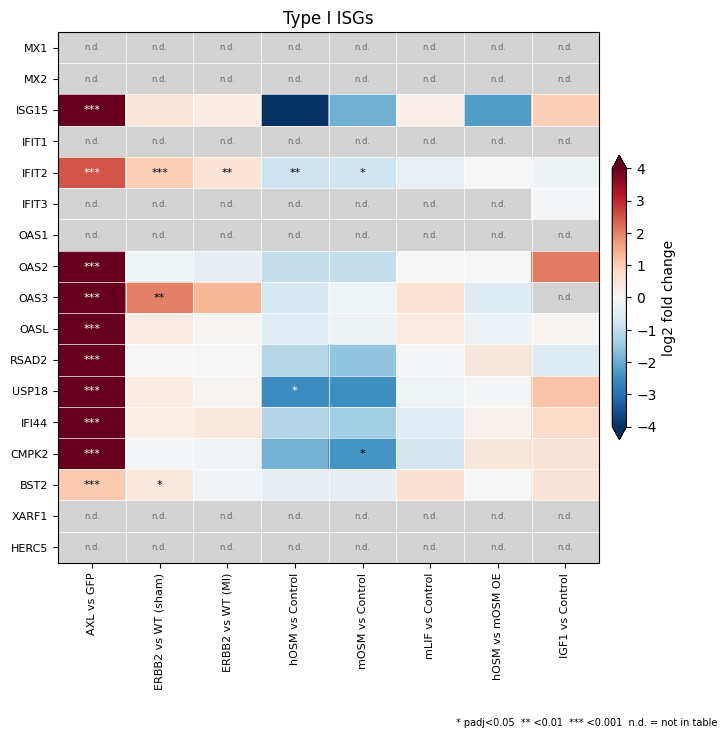

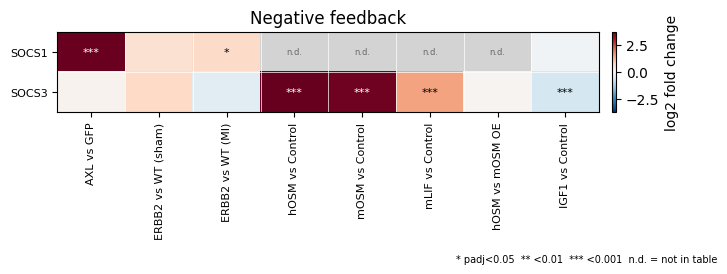

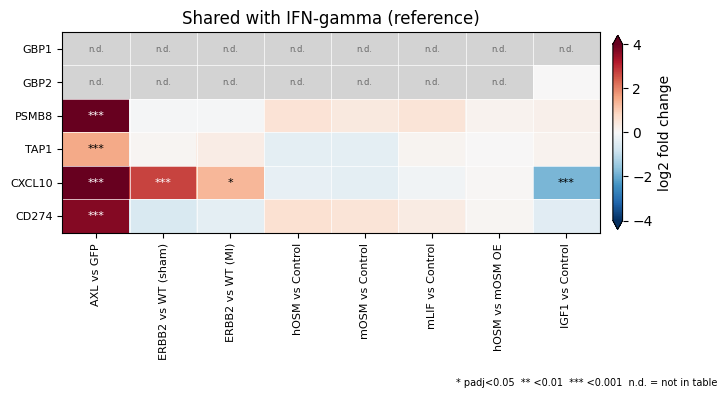

In [9]:
for panel in panels_to_plot:
    genes = gene_groups[panel]
    panel_lfc = long.loc[long.group == panel, 'log2FC'].abs()
    vmax = panel_lfc.max() if panel_lfc.notna().any() else 1
    if heatmap_lfc_cap is not None:
        vmax = min(vmax, heatmap_lfc_cap)

    fig, ax = plt.subplots(figsize=(0.6 * n_ds + 2.5, 0.3 * len(genes) + 2))
    im = draw_lfc_heatmap(ax, genes, vmax)
    cbar = fig.colorbar(im, ax=ax, shrink=min(1.0, 4 / len(genes) + 0.3), pad=0.02,
                        extend='both' if panel_lfc.max() > vmax else 'neither')
    cbar.set_label('log2 fold change')
    ax.set_title(panel)
    fig.text(0.99, -0.03, '* padj<0.05  ** <0.01  *** <0.001  n.d. = not in table',
             ha='right', fontsize=7)
    plt.tight_layout()

    fname = panel.lower().replace(' ', '_').replace('(', '').replace(')', '').replace('-', '')
    plt.savefig(f'{figures_dir}/{out_prefix}_heatmap_{fname}.png', dpi=300, bbox_inches='tight')
    plt.savefig(f'{figures_dir}/{out_prefix}_heatmap_{fname}.pdf', bbox_inches='tight')
    plt.show()

### All panels in one figure
One block per gene group, sharing the same colour scale so effect sizes are comparable across groups.

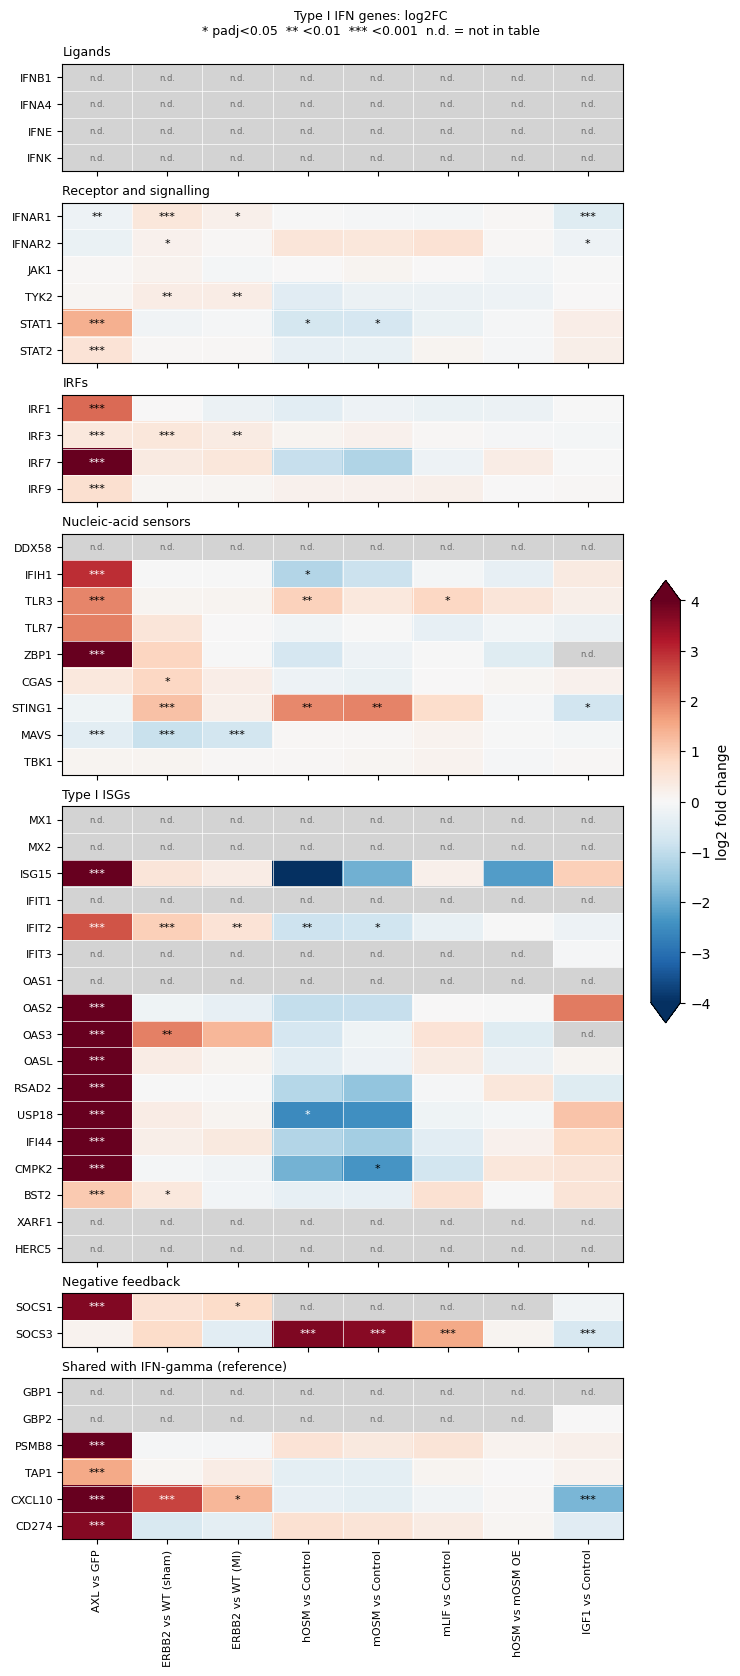

In [10]:
heights = [len(gene_groups[p]) for p in panels_to_plot]
all_lfc = long.loc[long.group.isin(panels_to_plot), 'log2FC'].abs()
vmax = all_lfc.max() if all_lfc.notna().any() else 1
if heatmap_lfc_cap is not None:
    vmax = min(vmax, heatmap_lfc_cap)

fig, axes = plt.subplots(len(panels_to_plot), 1, squeeze=False, layout='constrained',
                         figsize=(0.6 * n_ds + 2.5, 0.25 * sum(heights) + 0.45 * len(heights) + 1.5),
                         gridspec_kw={'height_ratios': heights})
axes = axes[:, 0]
for k, (ax, panel) in enumerate(zip(axes, panels_to_plot)):
    im = draw_lfc_heatmap(ax, gene_groups[panel], vmax, show_xticklabels=(k == len(axes) - 1))
    ax.set_title(panel, loc='left', fontsize=9)

cbar = fig.colorbar(im, ax=axes, shrink=0.3, aspect=15, extend='both' if all_lfc.max() > vmax else 'neither')
cbar.set_label('log2 fold change')
fig.suptitle('Type I IFN genes: log2FC\n* padj<0.05  ** <0.01  *** <0.001  n.d. = not in table', fontsize=9)

plt.savefig(f'{figures_dir}/{out_prefix}_heatmap_all_panels.png', dpi=300, bbox_inches='tight')
plt.savefig(f'{figures_dir}/{out_prefix}_heatmap_all_panels.pdf', bbox_inches='tight')
plt.show()